# Data Import and Function Definitions

## Import and process technology cost data

In [2]:
# @title Importing Libraries

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pypsa
import networkx as nx

In [3]:
# -----------------------------
# Settings
# -----------------------------
country = "DNK"
tech_year = 2025

# -----------------------------
# 1. Import technology costs like course notebook
# -----------------------------
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{tech_year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


ann = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]
costs["capital_cost"] = (ann + costs["FOM"] / 100) * costs["investment"]

techs = costs.loc[["solar", "onwind", "offwind", "OCGT"], ["capital_cost", "marginal_cost", "efficiency", "lifetime"]]
display(techs)

parameter,capital_cost,marginal_cost,efficiency,lifetime
technology,,,,
solar,63114.923985,0.010600,1.000,37.5
onwind,107441.457021,1.508000,1.000,28.5
offwind,184567.393550,0.021200,1.000,30.0
OCGT,48739.697513,65.423728,0.405,25.0


### Importing data

In [4]:
# Only use when working with Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# @title Importing capacity

# df = pd.read_csv(r"content/GenerationProdTypeExchange.csv", sep=";", decimal=",", low_memory=False)
df = pd.read_csv(r"/content/drive/MyDrive/Dokumendid/KOOL/DTU/Integrated Energy Grids/GenerationProdTypeExchange.csv", sep=";", decimal=",", low_memory=False)

# Select only relevant columns
cols = ["TimeDK", "GrossCon","OffshoreWindPower","OnshoreWindPower","SolarPower"]
df_sorted = df[cols]

# -------------
# Fixing timing
# -------------

# Setting timeDK as the index
df_sorted["TimeDK"] = pd.to_datetime(df_sorted["TimeDK"])
df_sorted = df_sorted.set_index("TimeDK")

# Sum hourly data,
#df = df.groupby(df.index.floor("h")).sum()
# Shouldn't it be mean?
df_sorted = df_sorted.groupby(df_sorted.index).mean()

# Enforce hourly structure
df_sorted = df_sorted.asfreq("h")

# -------------
# Calcualting the capacity factors
# -------------

# Creating capacity factor dataframe
capacity_factors = pd.DataFrame({
    "solar": df_sorted["SolarPower"]/ df_sorted["SolarPower"].max(),
    "onwind": df_sorted["OnshoreWindPower"] / df_sorted["OnshoreWindPower"].max(),
    "offwind": df_sorted["OffshoreWindPower"] / df_sorted["OffshoreWindPower"].max()
}).fillna(0.0)

# Creating a demand series
demand_series = pd.DataFrame({"demand": df_sorted["GrossCon"]}).fillna(0.0)

/tmp/ipykernel_10340/2398725740.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## Plotting Function Definitions

In [6]:
# @title Setting colours
colors = {
    "solar": "orange",
    "onwind": "green",
    "offwind": "blue",
    "OCGT": "firebrick",
    "battery": "limegreen",
    "H-turbine": "skyblue",
    "demand": "black"
}

In [7]:
winter_week_start = f"{tech_year}-01-01 00:00"
winter_week_end = f"{tech_year}-01-07 23:00"

summer_week_start = f"{tech_year}-07-01 00:00"
summer_week_end = f"{tech_year}-07-07 23:00"

In [8]:
# @title Extracting demand for summer and winter

demand_series_winter = demand_series.loc[winter_week_start:winter_week_end]
demand_series_summer = demand_series.loc[summer_week_start:summer_week_end]

In [9]:
# @title Dispatch plotting Fn

def plot_dispatch(dispatch_df, demand_series):
    fig, ax = plt.subplots(figsize=(14, 5))

    dispatch_df.plot.area(ax=ax, color=[colors.get(col, "gray") for col in dispatch_df.columns])
    demand_series.plot(ax=ax, color=colors.get("demand", "black"), linewidth=1.5, label="demand")

    ax.set_ylabel("Dispatched Power [MW]", size=10)
    ax.set_xlabel("Day in a Month", size=10)
    ax.set_title(f"Dispatch {dispatch_df.index.date.min()} until {dispatch_df.index.date.max()}", size=15)
    ax.legend(loc="upper left", ncol=2)

    # plt.tight_layout()
    plt.show()

In [10]:
# @title Annual mix plotting Fn

def plot_electricity_mix(annual_dispatch_df):
  fig, ax = plt.subplots(figsize=(8, 4))

  annual_generation = (annual_dispatch_df.sum() / 1000).round(2)
  annual_generation.plot(kind="bar", ax=ax, color=[colors.get(idx, "gray") for idx in annual_generation.index])

  ax.set_ylabel("Energy dispatch [GWh]", size=10)
  ax.set_xlabel("Generator")
  ax.set_title(f"Annual electricity mix ({annual_dispatch_df.index.year.min()})", size=15)

  plt.tight_layout()
  plt.show()

In [11]:
# @title State of Charge plot Fn

def plot_SoC(soc_series, time_unit):
    fig, ax = plt.subplots(figsize=(14, 5))

    soc_series.plot(figsize=(12,4), title="Battery State of Charge (%)", color=colors.get("battery"))

    ax.set_xlabel(f"Time [{time_unit}]")
    ax.set_ylabel("%")
    ax.set_title(f"SoC between {soc_series.index.min()} until {soc_series.index.max()}", size=15)
    ax.legend(loc="upper left", ncol=2)

    plt.tight_layout()
    plt.show()

# 1st Model Building (Generators and Demand)

In [12]:
# @title Available years

print("Choose a year between:")
display(capacity_factors.index.year.unique())

Choose a year between:


Index([2020, 2021, 2022, 2023, 2024, 2025], dtype='int32', name='TimeDK')

In [13]:
year = 2025

# Filtering out only the chosen year
# Python might say it cannot access 'year' but it works somehow -> #sketchy-engineering
cf_year = capacity_factors[capacity_factors.index.year == year].copy()
demand_year = demand_series[demand_series.index.year == year].copy()


# Initialising network
n = pypsa.Network()
n.set_snapshots(cf_year.index)

# Adding carriers
for carrier in ["electricity", "solar", "onwind", "offwind", "gas", "load_shedding"]:
    n.add("Carrier", carrier)

# Adding
n.add("Bus", "electricity", carrier="electricity")


n.add("Load", "demand", bus="electricity", p_set=demand_year["demand"])

n.add(
    "Generator",
    "solar",
    bus="electricity",
    carrier="solar",
    p_nom_extendable=True,
    p_max_pu=cf_year["solar"],
    capital_cost=costs.at["solar", "capital_cost"],
    marginal_cost=costs.at["solar", "marginal_cost"],
)

n.add(
    "Generator",
    "onwind",
    bus="electricity",
    carrier="onwind",
    p_nom_extendable=True,
    p_max_pu=cf_year["onwind"],
    capital_cost=costs.at["onwind", "capital_cost"],
    marginal_cost=costs.at["onwind", "marginal_cost"],
)

n.add(
    "Generator",
    "offwind",
    bus="electricity",
    carrier="offwind",
    p_nom_extendable=True,
    p_max_pu=cf_year["offwind"],
    capital_cost=costs.at["offwind", "capital_cost"],
    marginal_cost=costs.at["offwind", "marginal_cost"],
)

n.add(
    "Generator",
    "OCGT",
    bus="electricity",
    carrier="gas",
    p_nom_extendable=True,
    capital_cost=costs.at["OCGT", "capital_cost"],
    marginal_cost=costs.at["OCGT", "marginal_cost"],
)

n.add(
    "Generator",
    "load_shedding",
    bus="electricity",
    carrier="load_shedding",
    p_nom=float(demand_year["demand"].max()),
    marginal_cost=10_000,
)

# 1st Model Optimisation

In [14]:
n.optimize(solver_name="highs")

/tmp/ipykernel_10340/3144390136.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 110.36it/s]


('ok', 'optimal')

## 1st Model Data Preparation

In [15]:
# @title Preparing data for plotting

# Copy the power dispatch to a new dataframe
dispatch = n.generators_t.p.copy()

# Exclude load shedding
dispatch_plot = dispatch.drop(columns="load_shedding", errors="ignore")

# Annual generation in GWh
annual_generation = (dispatch_plot.sum() / 1000).round(2)

# Capacity factors
capacities = n.generators["p_nom_opt"].drop("load_shedding", errors="ignore")
capacity_factors = (
    dispatch_plot.sum() / (capacities * len(n.snapshots))
).fillna(0).round(3)

# Defining summer and winter dispatches
summer = dispatch_plot.loc[summer_week_start:summer_week_end]
winter = dispatch_plot.loc[winter_week_start:winter_week_end]

## 1st Model Results

In [16]:
# @title Numerical results
print("Optimal capacities (MW)")
display(capacities.round(2))

print("\nAnnual generation (GWh)")
display(annual_generation)

print("\nCapacity factors")
display(capacity_factors)

Optimal capacities (MW)


,p_nom_opt
name,
solar,2044.78
onwind,2861.25
offwind,713.16
OCGT,2803.19



Annual generation (GWh)


,0
name,
solar,2407.67
onwind,6335.43
offwind,2561.14
OCGT,8426.54



Capacity factors


,0
name,
solar,0.134
onwind,0.253
offwind,0.410
OCGT,0.343


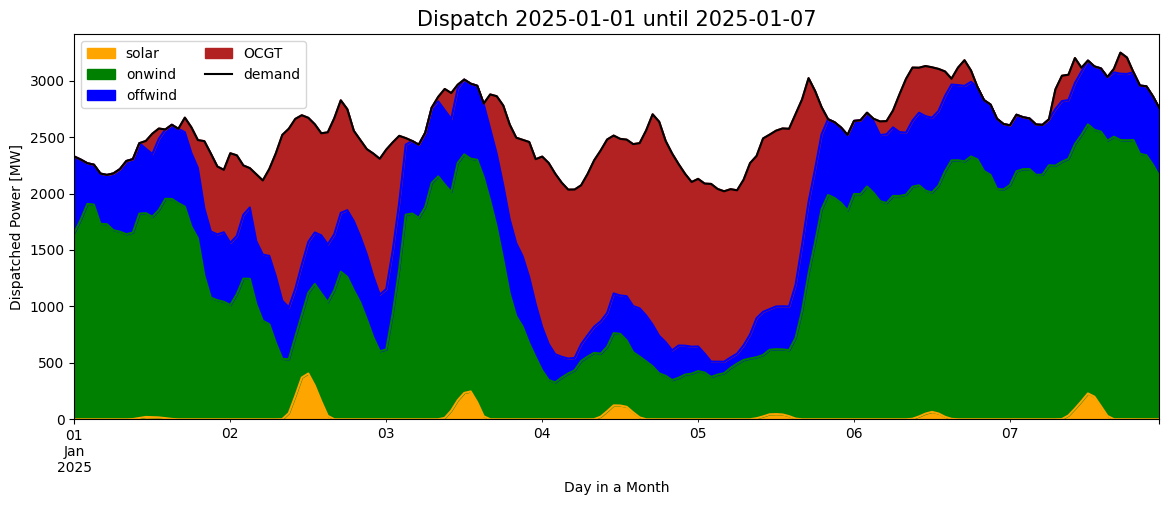

In [17]:
# @title Winter week dispatch

plot_dispatch(winter, demand_series.loc[winter.index])

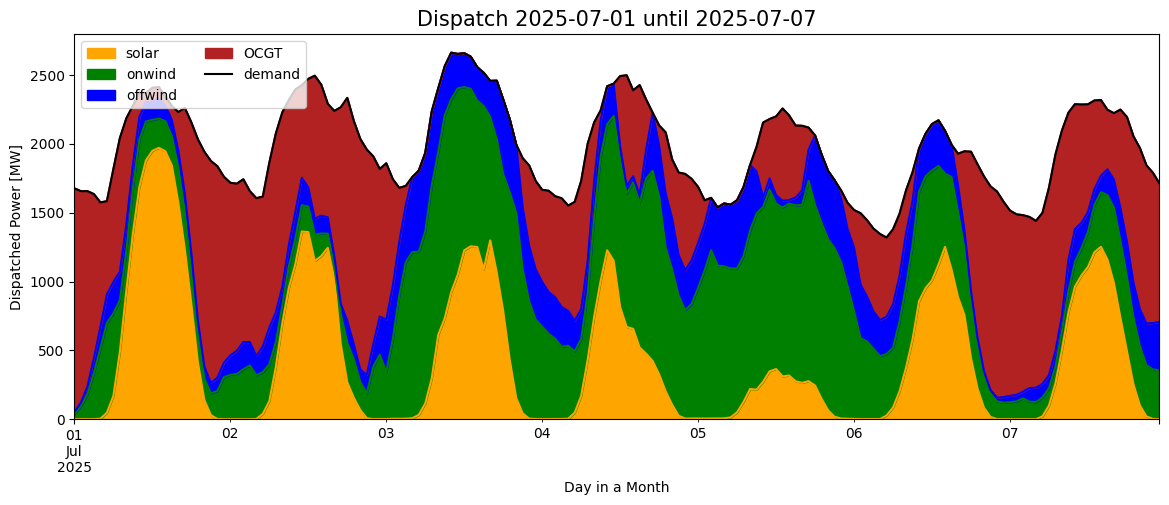

In [18]:
# @title Summer week dispatch

plot_dispatch(summer, demand_series.loc[summer.index])

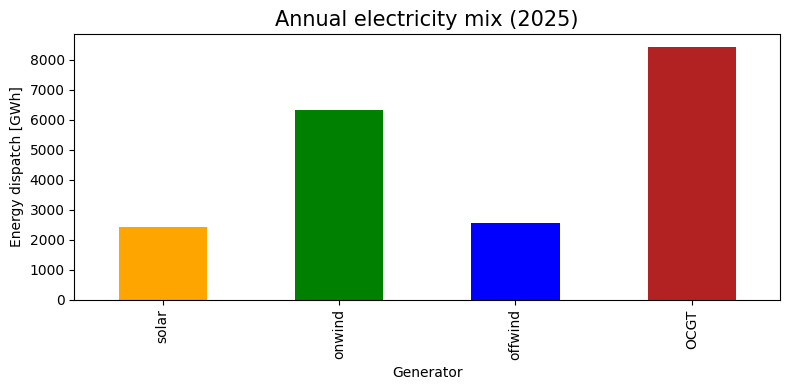

In [19]:
# @title Annual electricity mix

plot_electricity_mix(dispatch_plot)

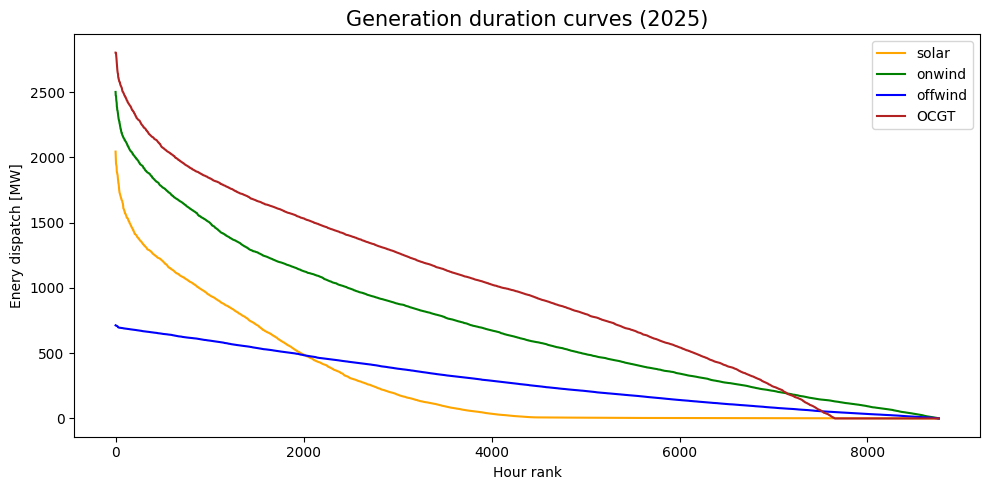

In [20]:
# @title Duration curve

fig, ax = plt.subplots(figsize=(10, 5))
for col in dispatch_plot.columns:
    dispatch_plot[col].sort_values(ascending=False).reset_index(drop=True).plot(ax=ax, label=col, color=colors.get(col, "gray"))

ax.set_xlabel("Hour rank", size=10)
ax.set_ylabel("Enery dispatch [MW]", size=10)
ax.set_title(f"Generation duration curves ({tech_year})", size=15)
ax.legend()
plt.tight_layout()
plt.show()

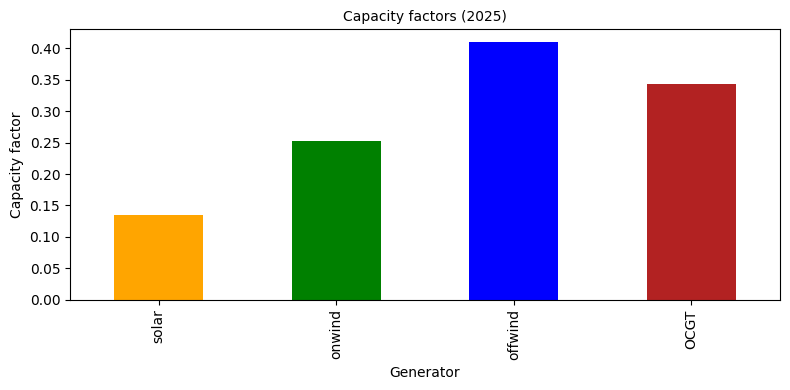

In [21]:
# @title Capacity factor chart

fig, ax = plt.subplots(figsize=(8, 4))
capacity_factors.plot(kind="bar", ax=ax, color=[colors.get(idx, "gray") for idx in capacity_factors.index])
ax.set_ylabel("Capacity factor", size=10)
ax.set_xlabel("Generator", size=10)
ax.set_title(f"Capacity factors ({tech_year})", size=10)
plt.tight_layout()
plt.show()

# 2nd Model Building (Storage Added)

In [22]:
# @title Adding battery storage components

n.add("StorageUnit",
      "battery",
      bus="electricity",
      p_nom_extendable=True,

      max_hours=4,  # energy = 4h * power
      # might be due to change. Depends on the realistic scale and needs. Can be separated to energy and power.

      #capital_cost=400,  # €/kW (power cost)
      capital_cost=(costs.at["Lithium-Ion-NMC-bicharger", "capital_cost"] + costs.at["Lithium-Ion-NMC-store", "capital_cost"]),
      marginal_cost=costs.at["Lithium-Ion-NMC-bicharger", "marginal_cost"],

      efficiency_store=0.95,
      efficiency_dispatch=0.95,

      cyclic_state_of_charge=True,
      overwrite=True)

In [23]:
# @title Adding H-bus and H components

n.add("Bus", "hydrogen", carrier="hydrogen", overwrite=True)

n.add("Link",
      "electrolyser",
      bus0="electricity",
      bus1="hydrogen",

      p_nom_extendable=True,
      efficiency=0.70,

      p_min_pu = 0, # Min power flow is 0 and not negative:
      # we want to restrict H energy being converted into electrical energy here
      # as the electrolizer is monodirectional energy converter.

      capital_cost=costs.at["PEM electrolyzer", "capital_cost"],
      overwrite=True)

n.add("Store",
      "hydrogen_storage",
      bus="hydrogen",

      e_nom_extendable=True,
      capital_cost=costs.at["hydrogen storage underground", "capital_cost"],

      e_cyclic=True,
      overwrite=True)

n.add("Link",
      "hydrogen_turbine",
      bus0="hydrogen",
      bus1="electricity",

      p_nom_extendable=True,
      efficiency=0.50,

      p_min_pu = 0, # Min power flow is 0 and not negative:
      # we want to restrict electrical energy being converted into H here
      # as the gas turbine is monodirectional energy converter.

      capital_cost=costs.at["fuel cell", "capital_cost"],
      overwrite=True)

# 2nd Model Optimisation

In [24]:
n.optimize(solver_name="highs")

/tmp/ipykernel_10340/3144390136.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['hydrogen'], dtype='object', name='name')
Index(['hydrogen_turbine'], dtype='object', name='name')
Index(['hydrogen_storage'], dtype='object', name='name')
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 198.29it/s]


('ok', 'optimal')

## 2nd Model Results Preparation

In [25]:
# @title Extracting different dispatches

# Exclude load shedding
dispatch = n.generators_t.p.drop(columns="load_shedding", errors="ignore").copy()
battery_dispatch = n.storage_units_t.p_dispatch["battery"].copy()
H_dispatch = -n.links_t.p1["hydrogen_turbine"].copy()

# Exclude load shedding
dispatch_clean = dispatch.drop(columns="load_shedding", errors="ignore")

In [26]:
# @title Calculating common dispatch

# Adding battery and H turbine to the dispatch
common_dispatch = dispatch.copy()
common_dispatch["battery"] = battery_dispatch.round().abs()
common_dispatch["H-turbine"] = H_dispatch

# Creating summer and winter dataframes
common_dispatch_winter = common_dispatch.loc[winter_week_start:winter_week_end]
common_dispatch_summer = common_dispatch.loc[summer_week_start:summer_week_end]

In [27]:
# @title Calculating state of charge [%]

soc = n.storage_units_t.state_of_charge["battery"]
e_nom = n.storage_units.p_nom_opt["battery"] * n.storage_units.max_hours["battery"]

soc_percent = 100 * soc / e_nom

In [28]:
# @title Calcualting annual generation

annual_generation = (common_dispatch.sum() / 1000).round(2)

In [29]:
# @title Calculating capacities and capacity factors

gen_capacities = n.generators["p_nom_opt"].drop("load_shedding", errors="ignore")

storage_capacities = n.storage_units["p_nom_opt"]

common_capacities = gen_capacities.copy()
common_capacities["battery"] = storage_capacities["battery"]

capacity_factors = (
    common_dispatch.sum() / (common_capacities * len(n.snapshots))
).fillna(0).round(3)

## 2nd Model Results Plotting

In [30]:
# @title Numerical Values

print("Optimal capacities (MW)")
display(common_capacities.round(2))

print("\nAnnual generation (GWh)")
display(annual_generation)

print("\nCapacity factors")
display(capacity_factors)

Optimal capacities (MW)


,p_nom_opt
name,
solar,2327.57
onwind,2820.61
offwind,758.73
OCGT,2584.14
battery,278.79



Annual generation (GWh)


,0
name,
solar,2740.63
onwind,6279.84
offwind,2724.77
OCGT,7998.17
battery,115.02
H-turbine,0.00



Capacity factors


,0
name,
H-turbine,0.000
OCGT,0.353
battery,0.047
offwind,0.410
onwind,0.254
solar,0.134


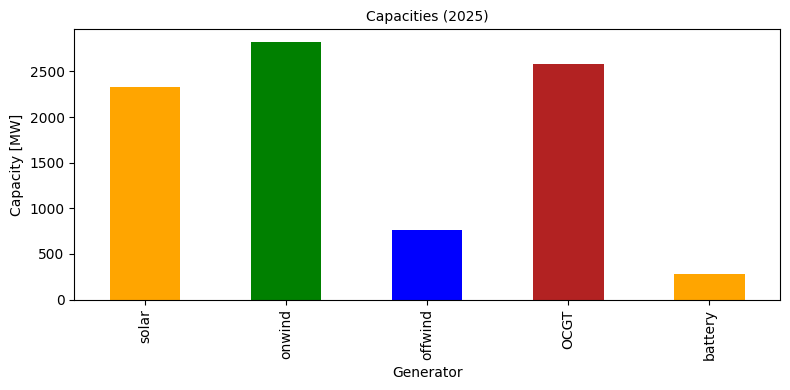

In [31]:
# @title Capacities visualisation
fig, ax = plt.subplots(figsize=(8, 4))

common_capacities.plot(kind="bar", ax=ax, color=[colors.get(idx, "gray") for idx in gen_capacities.index])
#storage_capacities.plot(kind="bar", ax=ax, color=[colors.get(idx, "gray") for idx in storage_capacities.index])

ax.set_ylabel("Capacity [MW]", size=10)
ax.set_xlabel("Generator", size=10)
ax.set_title(f"Capacities ({tech_year})", size=10)
plt.tight_layout()
plt.show()

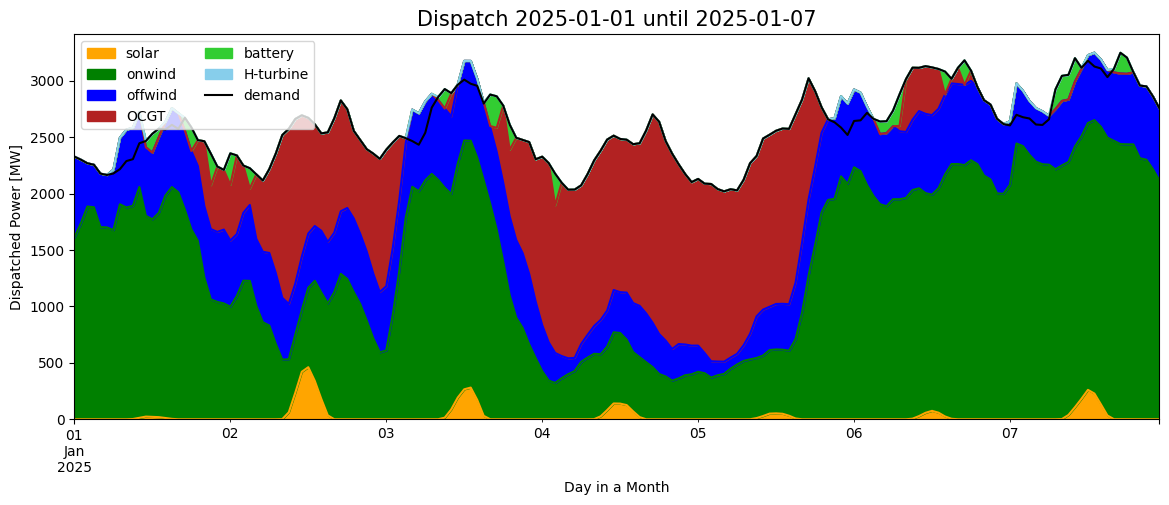

In [32]:
# @title Winter week dispatches
plot_dispatch(common_dispatch_winter, demand_series_winter)

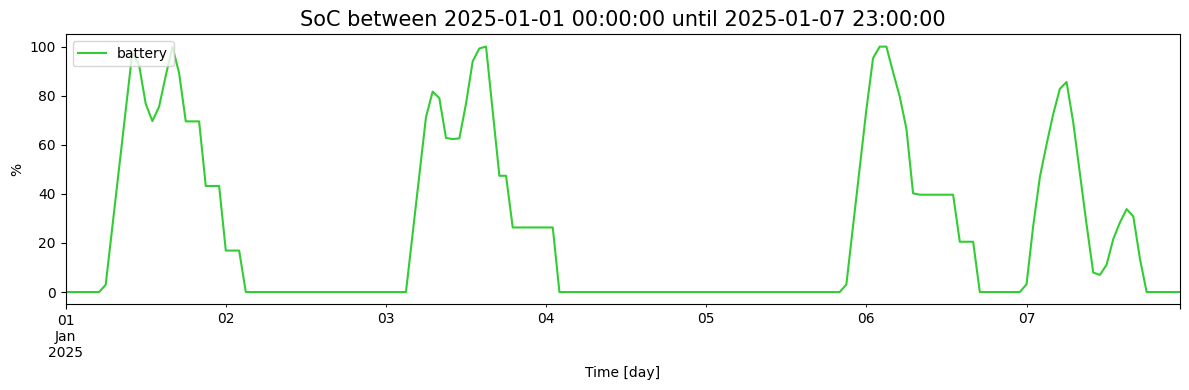

In [33]:
# @title Winter week SoC
plot_SoC(soc_percent.loc[winter_week_start:winter_week_end], "day")

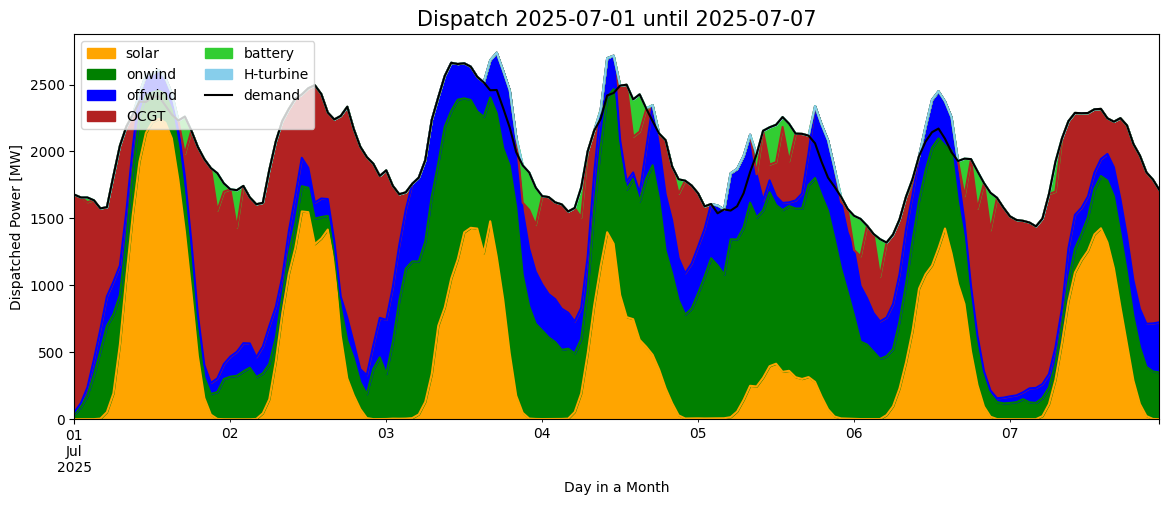

In [34]:
# @title Summer week dispatches
plot_dispatch(common_dispatch_summer, demand_series_summer)

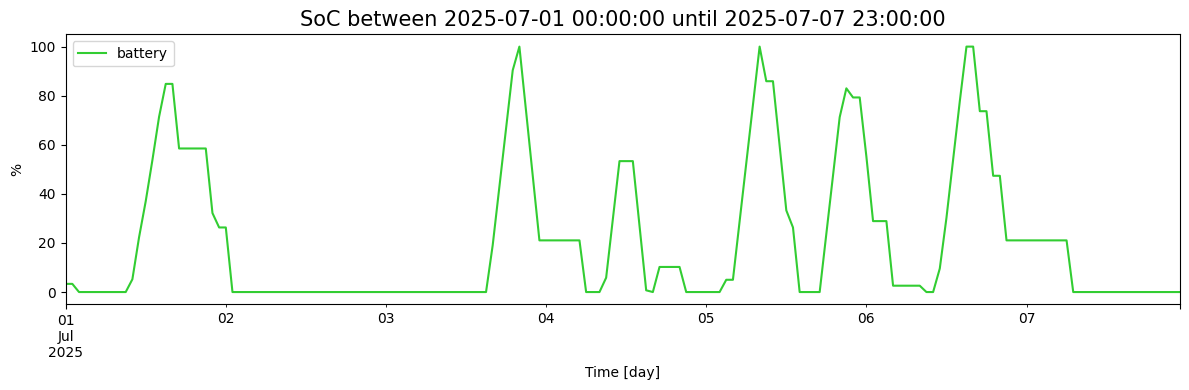

In [35]:
# @title Summer week SoC
plot_SoC(soc_percent.loc[summer_week_start:summer_week_end], "day")

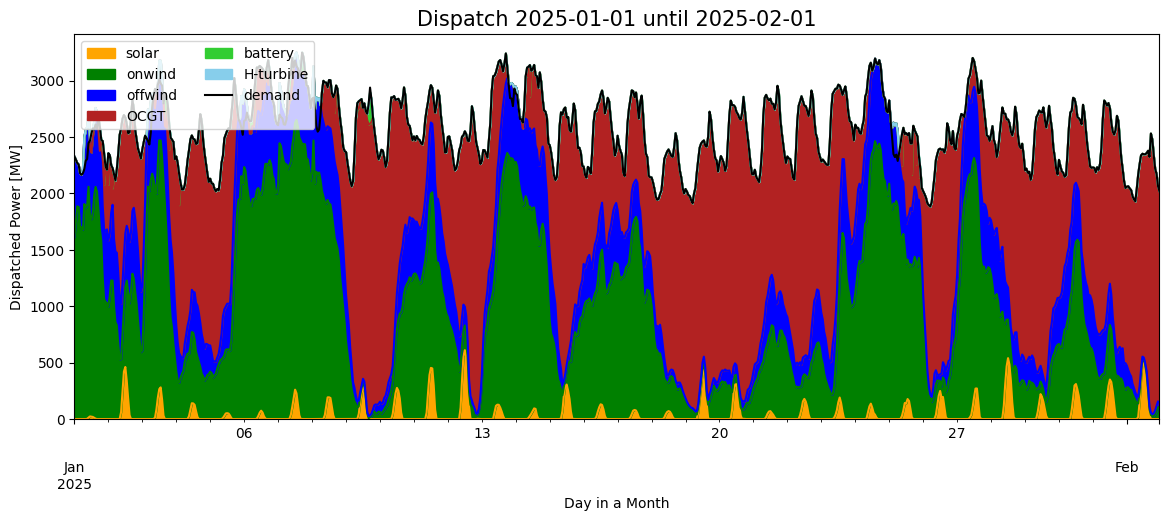

In [36]:
# @title Common Disptach - January
month_start = f"{tech_year}-01-01"
month_end = f"{tech_year}-02-01"

plot_dispatch(common_dispatch.loc[month_start:month_end], demand_series.loc[month_start:month_end])

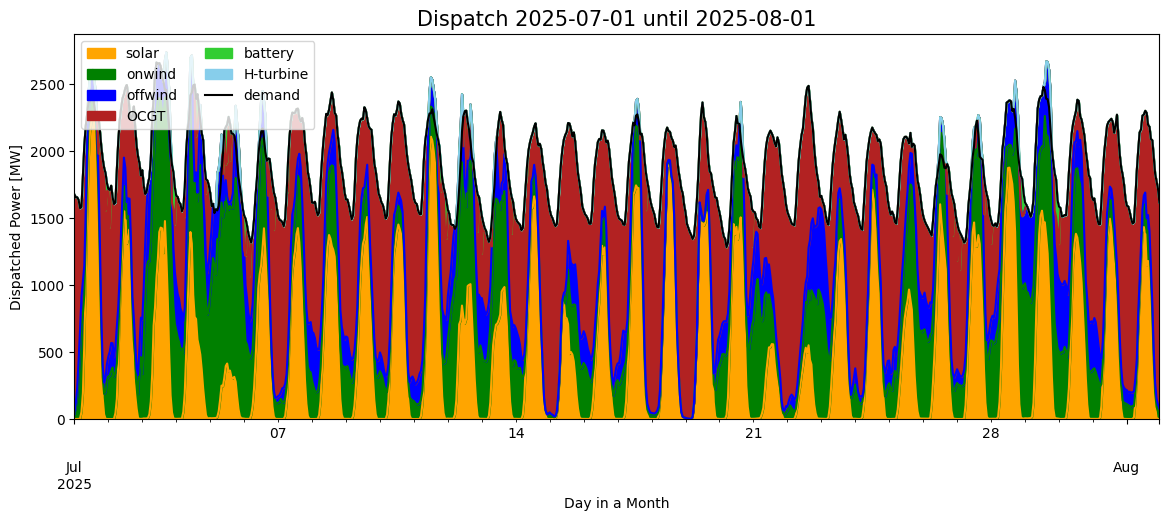

In [37]:
# @title Common Disptach - June
month_start = f"{tech_year}-07-01"
month_end = f"{tech_year}-08-01"

plot_dispatch(common_dispatch.loc[month_start:month_end], demand_series.loc[month_start:month_end])

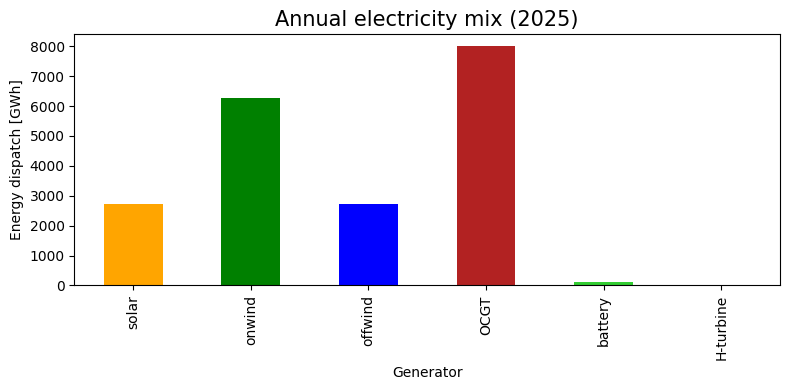

In [38]:
# @title New annual electricity mix

plot_electricity_mix(common_dispatch)

In [ ]:
# @title Single resource dispatch (not used)

fig, ax = plt.subplots(figsize=(14, 5))
jan_month_start = f"{tech_year}-01-01 00:00"
jan_month_end = f"{tech_year}-02-01 00:00"

resource = "solar"

def plot_single_dispatch(dispatch_df, resource, demand):
  fig, ax = plt.subplots(figsize=(14, 5))

  dispatch_df[resource].loc[jan_month_start:jan_month_end].plot.area(ax=ax, color=[colors.get(resource)])
  demand_series.loc[jan_month_start:jan_month_end].plot(ax=ax, color=colors.get("demand"), linewidth=1.5, label="demand")

  ax.set_ylabel("MW")
  ax.set_title(f"Dispatch of {resource} – February {year}")
  ax.set_xlabel("Day in the Month")
  ax.legend(loc="upper left", ncol=2)

  plt.tight_layout()
  plt.show()